In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [5]:
df = pd.read_csv("student-data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (395, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,no
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,no
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,yes
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,yes
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,yes


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (395, 31)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'passed']

Data Types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
passed          str
dtype: 

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
passed        0
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (395, 31)


In [11]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu', 'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences', 'passed']


In [12]:
df.describe(include="object")

C:\Users\SUJAL\AppData\Local\Temp\ipykernel_4232\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,school,sex,address,famsize,pstatus,mjob,fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,passed
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no,yes
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263,265


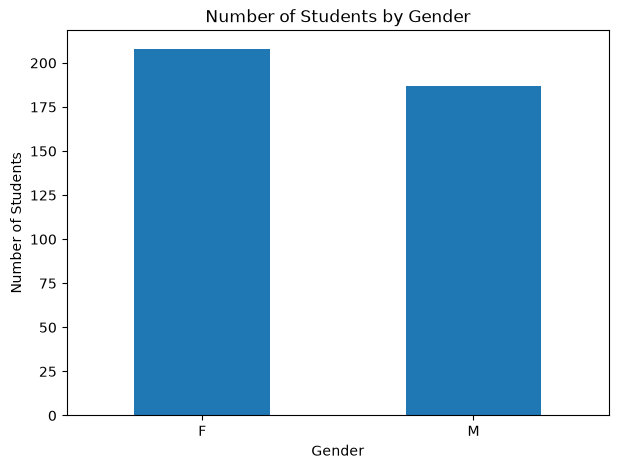

In [14]:
plt.figure(figsize=(7, 5))

df["sex"].value_counts().plot(kind="bar")

plt.title("Number of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

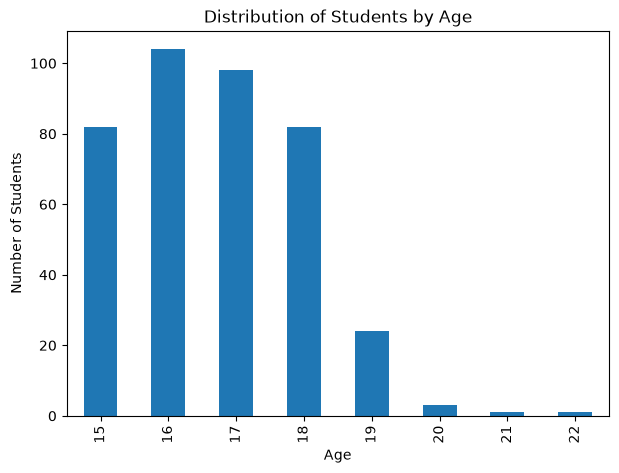

In [16]:
plt.figure(figsize=(7, 5))

df["age"].value_counts().sort_index().plot(kind = "bar")

plt.title("Distribution of Students by Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

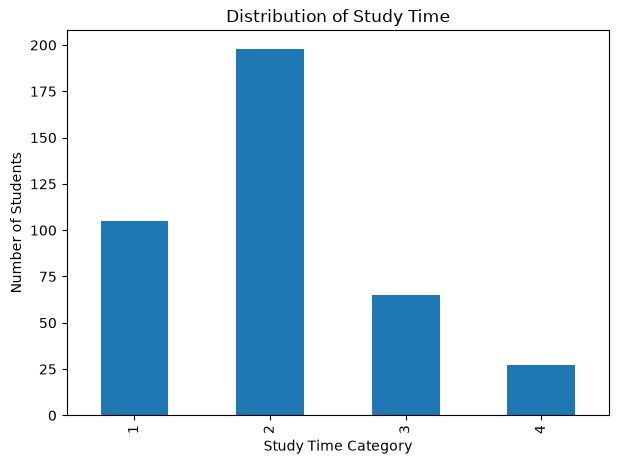

In [17]:
plt.figure(figsize=(7, 5))

df["studytime"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

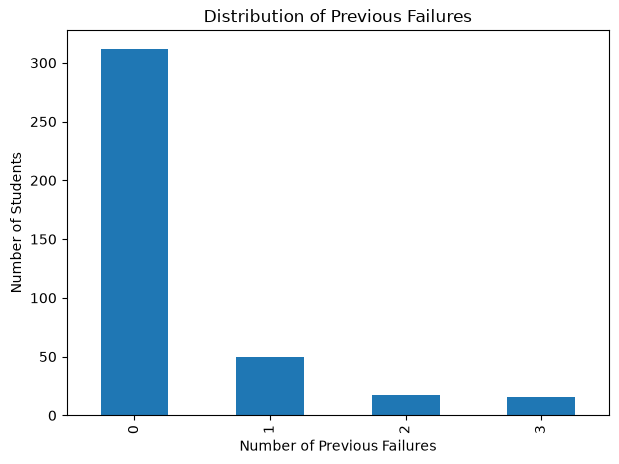

In [18]:
plt.figure(figsize=(7, 5))

df["failures"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

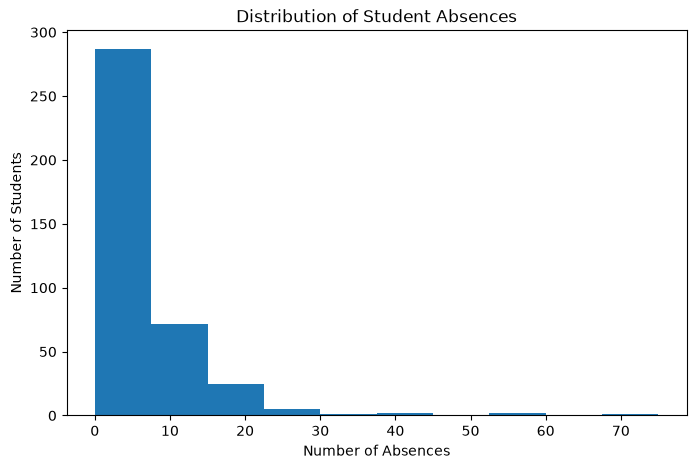

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(df["absences"], bins=10)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

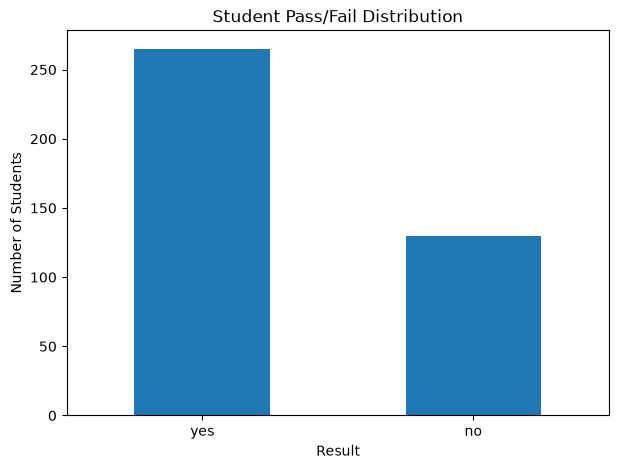

In [20]:
plt.figure(figsize=(7, 5))

df["passed"].value_counts().plot(kind="bar")

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

In [21]:
print(df["passed"].value_counts())

passed
yes    265
no     130
Name: count, dtype: int64


In [24]:
x = df.drop("passed", axis=1)
y = df["passed"]

print("Features:", x.shape)
print("Target:", y.shape)

Features: (395, 30)
Target: (395,)


In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (316, 30)
Testing data: (79, 30)


In [27]:
numeric_features = x.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = x.select_dtypes(
    include=["object"]
).columns

print("Numerical Feature:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Feature:
['age', 'medu', 'fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'dalc', 'walc', 'health', 'absences']

Categorical Features:
['school', 'sex', 'address', 'famsize', 'pstatus', 'mjob', 'fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\SUJAL\AppData\Local\Temp\ipykernel_4232\696998485.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(


In [29]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("onehot", OneHotEncoder(handle_unknown="ignore"))
        
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [30]:
model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter = 1000))
    ]
)

In [31]:
model.fit(x_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [32]:
y_pred = model.predict(x_test)

print("Predictions:")
print(y_pred)

Predictions:
['no' 'no' 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes'
 'yes' 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'
 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'yes' 'yes' 'yes' 'no' 'yes' 'no'
 'yes' 'no' 'yes' 'no' 'yes' 'yes' 'no' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'no' 'yes' 'yes'
 'yes' 'yes' 'yes' 'yes' 'yes' 'yes']


In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    pos_label="yes"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="yes"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="yes"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.6582278481012658
Precision : 0.7166666666666667
Recall : 0.8113207547169812
F1 Score : 0.7610619469026548


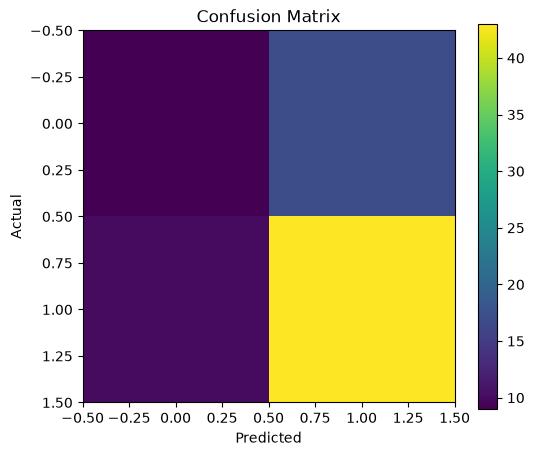

Confusion Matrix:
[[ 9 17]
 [10 43]]


In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

print("Confusion Matrix:")
print(cm)

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.47      0.35      0.40        26
         yes       0.72      0.81      0.76        53

    accuracy                           0.66        79
   macro avg       0.60      0.58      0.58        79
weighted avg       0.64      0.66      0.64        79

